In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('emotion_train.csv')
print(len(data))
print(data.info())
data.head(10)

In [ ]:
X = data['text']
Y = data['label']

16000

In [ ]:
def split_data(X , Y , train_size):
    return X[: train_size] , X[train_size :] , Y[: train_size] , Y[train_size :]

X = data['text']
Y = data['label']

len_train = int(len(data) * 0.8)
len_test = len(data) - len_train
x_train , x_test , y_train , y_test = split_data(X , Y , len_train)

print(len(x_train))
print(len(x_test))
print(len(y_train))
print(len(y_test))

#

In [15]:
# replace_list = {r"i'm": 'i am',
#                 r"'re": ' are',
#                 r"let’s": 'let us',
#                 r"'s":  ' is',
#                 r"'ve": ' have',
#                 r"can't": 'can not',
#                 r"cannot": 'can not',
#                 r"shan’t": 'shall not',
#                 r"n't": ' not',
#                 r"'d": ' would',
#                 r"'ll": ' will',
#                 r"'scuse": 'excuse',
#                 ',': ' ,',
#                 '.': ' .',
#                 '!': ' !',
#                 '?': ' ?',
#                 '\s+': ' '}
# def clean_text(text):
#     text = text.lower()
#     for s in replace_list:
#         text = text.replace(s , replace_list[s])
#     text = ' '.join(text.split())
#     return text

In [16]:
# X = X.apply(clean_text)
# print(X[:5])

In [ ]:
# from nltk.corpus import stopwords
# import nltk

# nltk.download('stopwords')
# stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Aziz\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# def remove_stopwords(text):
#     words = text.split()
#     words = [w for w in words if w not in stop_words]
#     return ' '.join(words)

max phrase len: 66


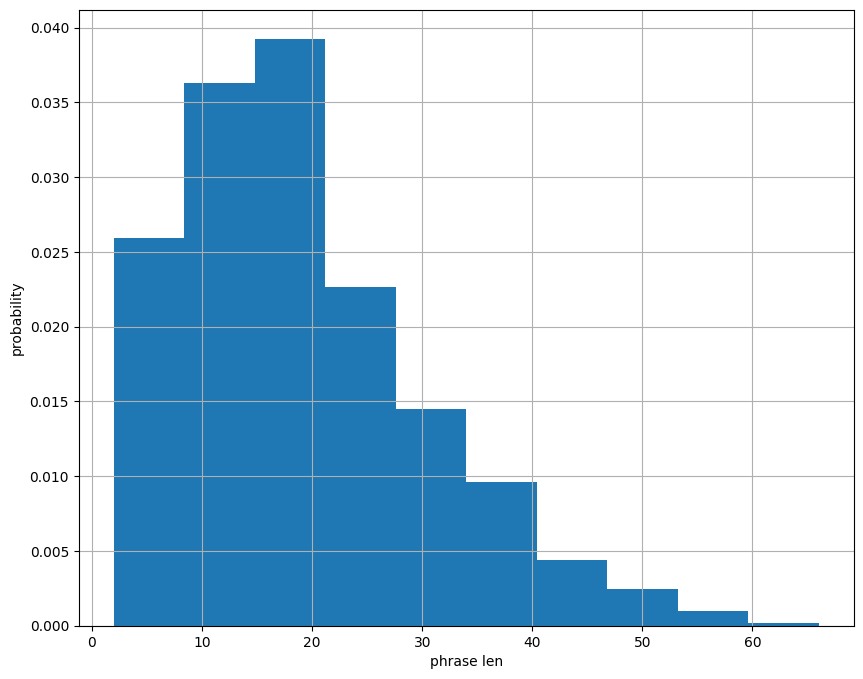

In [ ]:
phrase_len = x_train.apply(lambda p : len(p.split(' ')))
max_phrase_len = phrase_len.max()
print('max phrase len: {0}'.format(max_phrase_len))
plt.figure(figsize = (10 , 8))
plt.hist(phrase_len , density = True)
plt.xlabel('phrase len')
plt.ylabel('probability')
plt.grid()

In [18]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical 

# x_train = x_train.tolist()
# x_train = [str(t) for t in x_train]

vocab_size = 10000
tokenizer = Tokenizer(
    num_words = vocab_size,
    oov_token="<OOV>",
)
tokenizer.fit_on_texts(x_train)
x_train = tokenizer.texts_to_sequences(x_train)
x_train = pad_sequences(x_train , maxlen = max_phrase_len)

In [ ]:
# from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()


# le.fit(['neutral', 'joy', 'sadness', 'fear', 'surprise', 'anger', 'shame', 'disgust'])


# y_train = le.transform(y_train)
# y_test = le.transform(y_test)


# print(y_train[:10]) 
# print(y_test[:10])

[4 3 5 3 3 2 5 7 7 7]
[3 5 7 4 0 3 4 7 2 4]


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Embedding, Dropout, Dense , Bidirectional
from tensorflow.keras import optimizers

In [20]:
# embedding_dim = 100 

# model = Sequential()
# model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_phrase_len))
# model.add(Dropout(0.3))

# model.add(LSTM(64))
# model.add(Dropout(0.3))

# model.add(Dense(64, activation='relu'))
# model.add(Dropout(0.3))

# model.add(Dense(len(le.classes_), activation='softmax')) 

model = Sequential()

model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_phrase_len))
model.add(Dropout(0.3))

model.add(Bidirectional(LSTM(128)))
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(27, activation='softmax'))

c:\Users\Aziz\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [21]:
opt = optimizers.Adam(learning_rate = 0.001 , decay = 1e-6)

c:\Users\Aziz\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [22]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer = opt,
    metrics=['accuracy']
)


In [23]:
num_epochs = 3

In [24]:
history = model.fit(
    x_train,
    y_train,
    epochs=num_epochs,
    # verbose=2
)

Epoch 1/3
400/400 ━━━━━━━━━━━━━━━━━━━━ 72s 162ms/step - accuracy: 0.3420 - loss: 1.6917
Epoch 2/3
400/400 ━━━━━━━━━━━━━━━━━━━━ 67s 167ms/step - accuracy: 0.7803 - loss: 0.6562
Epoch 3/3
400/400 ━━━━━━━━━━━━━━━━━━━━ 80s 162ms/step - accuracy: 0.9234 - loss: 0.2515


In [220]:
# model.save('model.keras')

In [25]:
x_test = tokenizer.texts_to_sequences(x_test)
x_test = pad_sequences(x_test, maxlen=max_phrase_len)

In [26]:
# from tensorflow import keras

# model = keras.models.load_model("model.keras")

In [27]:
y_pred = model.evaluate(x_test , y_test)

100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.9169 - loss: 0.2595
